In [17]:
!find /home/david/FieldWork/Soufriere-Guadeloupe/Thermography/ -name "*imAve*" | sort -h

/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2017-10-31_NAPN/20171031_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-05_CSC/20180305_CSC_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-05_CSN/20180305_CSN_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-05_CSN/20180305_CSN_imAve.png
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-05_CSS/AA030506_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-27_CSC/20180327_CSC_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-27_CSN/20180327_CSN_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-27_NAPE/20180327_NAPE_imAve_bt.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-27_NAPN/20180327_NAPN_imAve.tif
/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2019-04-25_CSS/20190425_CSS_imAve_bt.tif


## TO DO
- Make a list of all viable observations
- Extract approximate plume trajectories for each
- Does "true_location_width" actually work?


|Date | Site | imAve |
|-----|------|-------|
|2017-10-31 | NAPN | True  |
|2018-03-05 | CSN  | True  |
|2018-03-27 | CSN  | True  |
|2018-03-27 | NAPE | True  |
|2018-03-27 | NAPN | True  |
|2019-04-25 | CSC  | False |
|2019-04-25 | CSN  | False |
|2019-04-25 | CSS  | True  |


In [2]:
%reload_ext autoreload
%autoreload 3 -p

from bent_plume_analyser import (gaussian_profile, show_scaled_image, image_extent,
                                 plume_angle, true_location_width, dist_along_path,
                                )
from fumarole_plume_model import derivs, load_ics_parameters, objective_fn, load_expt_data
from timeseries_analysis.timeseries_analysis import butter_lowpass_filtfilt
from scipy.io import loadmat
from scipy.integrate import ode, solve_ivp
from matplotlib.ticker import MultipleLocator

import pandas 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys
import json
import tifffile

# Set numpy options, notably for the printing of floating point numbers
np.set_printoptions(precision=6)

# Set matplotlib options
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['image.cmap'] = 'gray'

## Natural plumes

In [4]:
# 
date  = '2018-03-05'
site  = 'CSN'
path  = f'/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/{date}_{site}/'  #2018-03-05_CSN/'

vent_loc     = (265.5194805194804, 480-348.07142857142856)
dist_to_vent = 8.44  # m, from logbook
wind_speed   = 1     # m/s
IFOV         = 1.53e-3  # rad - 15 mm IRBIS lens with FOV = 43.6
scale_factor = 1 / (2 * dist_to_vent * np.arctan(IFOV / 2))  # m / pixel
image_shape  = [480, 640]
extent       = image_extent(image_shape, scale_factor, vent_loc)

## DEFINE THE DISTANCE ALONG THE AXIS, THE ANGLE AND THE WIDTH OF THE PLUME
p = [[ 0.05      , 0.        ],
     [ 0.06655528, 0.13287715],
     [ 0.09434369, 0.45939095],
     [ 0.1429734 , 0.84842867],
     [ 0.23328573, 1.18883667],
     [ 0.30275675, 1.48061496],
     [ 0.455593  , 1.79323456],
     [ 0.55979953, 2.06417155],
     [ 0.65011186, 2.28647881],
     [ 0.82378941, 2.5643629 ],
     [ 1.01136117, 2.83529988],
     [ 1.23366844, 3.23128471],
     [ 1.31703366, 3.46053908],
     [ 1.46986991, 3.68979345],
     [ 1.61575906, 3.90073043],
     [ 1.78943661, 4.06493696],
     [ 2.09510911, 4.1760906 ],
     [ 2.67171858, 4.42618627]]


image_data = {'vent_loc':  vent_loc, 
              'dist_to_vent': dist_to_vent,
              'wind_speed': wind_speed,
              'IFOV': IFOV,
              'scale_factor': scale_factor,
              'extent': list(extent),
              'image_shape': image_shape,
              'trajectory': p}

with open(path + 'parameters.json', 'w') as f:
    json.dump(image_data, f)

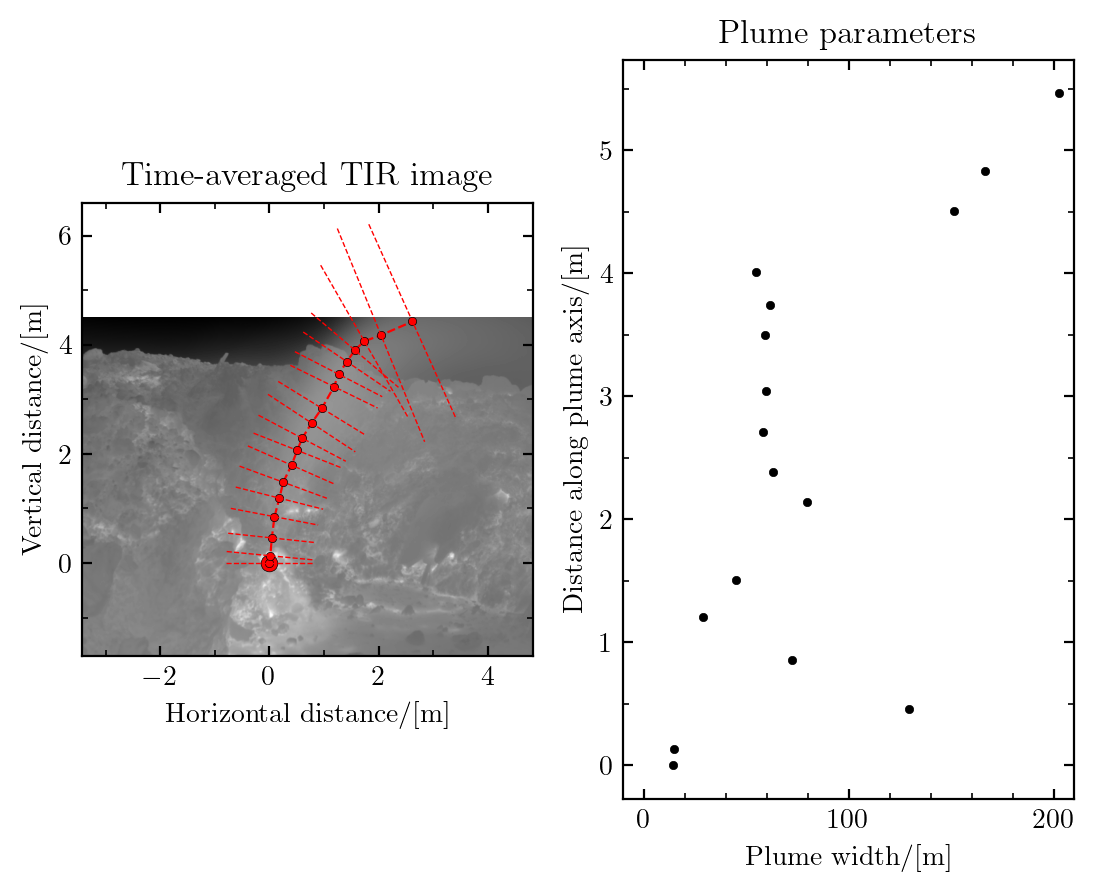

In [14]:
# path  = '/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/2018-03-05_CSN/'
# fname = '20180305_CSN_imAve_bt.tif'
fname = f'{date.replace('-', '')}_{site}_imAve_bt.tif'

data  = tifffile.imread(path + fname)
n, m  = np.array(data.shape) // 2

with open(path + 'parameters.json', 'r') as f:
    parameters = json.load(f)

fig, axes = plt.subplots(ncols=2, sharey=False)
extent, im, ax = show_scaled_image(data, scale_factor, vent_loc, ax=axes[0])
ax.plot(0, 0, 'or')  # vent location

## DEFINE THE DISTANCE ALONG THE AXIS, THE ANGLE AND THE WIDTH OF THE PLUME
p = np.array(parameters['trajectory'])
scale_factor = parameters['scale_factor']
vent_loc     = parameters['vent_loc']
# p = np.array([[ 0.05      , 0.        ],
#               [ 0.06655528, 0.13287715],
#               [ 0.09434369, 0.45939095],
#               [ 0.1429734 , 0.84842867],
#               [ 0.23328573, 1.18883667],
#               [ 0.30275675, 1.48061496],
#               [ 0.455593  , 1.79323456],
#               [ 0.55979953, 2.06417155],
#               [ 0.65011186, 2.28647881],
#               [ 0.82378941, 2.5643629 ],
#               [ 1.01136117, 2.83529988],
#               [ 1.23366844, 3.23128471],
#               [ 1.31703366, 3.46053908],
#               [ 1.46986991, 3.68979345],
#               [ 1.61575906, 3.90073043],
#               [ 1.78943661, 4.06493696],
#               [ 2.09510911, 4.1760906 ],
#               [ 2.67171858, 4.42618627]])

# p *= [1, -1]  # flipud the measurements
p += [-.05, 0]

pPixels = p.copy() * scale_factor + vent_loc
pPixels *= [1, -1]
pPixels += [0, 2*n]

ax.plot(p[:,0], p[:,1], '--.r', lw=.8)
ax.set_xlabel('Horizontal distance/[m]')
ax.set_ylabel('Vertical distance/[m]')
ax.set_title('Time-averaged TIR image')
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(1))

thexp, sig_thexp = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
thexp[0] = np.pi/2
_, bexp, sig_p, sig_bexp = true_location_width(data, p=pPixels, errors=[1/scale_factor])
sexp      = dist_along_path(p[:,0], p[:,1])

def _line(x, y, th, width=.5):
    x_ = np.array([-width, width])
    y_ = (x_) / np.tan(-th)
    return x_ + x, y_ + y
    
for th, p_ in zip(thexp, p):
    xs, ys = p_
    x_, y_ = _line(xs, ys, th, width=.8)
    ax.plot(x_, y_, '--r', lw=.5)
    # with np.printoptions(precision=3, suppress=False):
    #     print(f'{th:.3f}, {xs:.3f}, {ys:.3f}', x_, y_)

# print(np.vstack([bexp, sexp]).T)
# fig, ax = plt.subplots()
axes[1].plot(bexp, sexp, '.k')
axes[1].set_xlim([-10, 210])
axes[1].set_xlabel('Plume width/[m]')
axes[1].set_ylabel('Distance along plume axis/[m]')
axes[1].set_title('Plume parameters')
axes[1].xaxis.set_minor_locator(MultipleLocator(20))
axes[1].xaxis.set_major_locator(MultipleLocator(100))
axes[1].yaxis.set_minor_locator(MultipleLocator(.5))

## Experimental plumes

In [10]:
## Analysis of an experiment for a wind-bent plume (Carazzo et al., 2016)
exptNo = 3
# sexp  = exptData.distAlongAxis
# thexp = exptData.plumeAngle
# bexp  = exptData.plumeWidth
scale_factor = 1./72.

path = './data/ExpPlumes_for_Dai/exp%02d/' % exptNo
with open(path + 'exp%02d_initGuess.json' % exptNo) as f:
    data = json.load(f)
p = np.array(data['data'])

data = np.flipud(loadmat(path + 'gsplume.mat')['gsplume'])
xexp = loadmat(path + 'xcenter.mat')['xcenter'][0]
zexp = loadmat(path + 'zcenter.mat')['zcenter'][0]
Ox, Oz = (xexp[0], zexp[0])
xexp = (xexp - Ox) / scale_factor
zexp = (Oz - zexp) / scale_factor

pPixels = p.copy() * scale_factor
pPixels[:,0] += Ox
pPixels[:,1] -= Oz
pPixels[:,1] *= -1

# Calculate angle, width and distance along plume and errors
thexp, sig_thexp         = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
_, bexp, sig_p, sig_bexp = true_location_width(data, p=pPixels, errors=[1/scale_factor])
sexp                     = dist_along_path(p[:,0], p[:,1])
# bexp     /= scale_factor
# sig_bexp /= scale_factor
# bexp[0]   = 0.55 / 2
# thexp[0]  = np.pi / 2

/home/david/Modelling/fumarole_plume_model/bent_plume_analyser.py:436: RuntimeWarning: invalid value encountered in sqrt
  plume_width_err.append(np.sqrt(np.diag(pcov[-1])))


In [11]:
# Load initial conditions for a given experiment, run the model for those conditions 
# and then compare model and experimental data
pathname = '/home/david/Modelling/fumarole_plume_model/data/'
V0, p = load_ics_parameters(pathname, exptNo)
#%run fumarolePlumeModel.py
V0[0] *= 2.

# Initialise an integrator object
r = ode(derivs).set_integrator('lsoda', nsteps=1e6)
r.set_initial_value(V0, 0.)
r.set_f_params(p)
V = [V0]    # State vector
s = [0.]    # Axial distance

# Set integration domain and step size
t1 = 30.
dt = .1

# Integrate, whilst successful, until the domain size is reached
while r.successful() and r.t < t1:
    r.integrate(r.t + dt)
    V.append(r.y)
    s.append(r.t)

In [12]:
s = np.array(s)
V = np.array(V)
    
# Calculate the model predictions
# Extract the plume parameters from the state vector
q     = V[:,0]
m     = V[:,1]
f     = V[:,2]
theta = V[:,3]

# Calculate more intuitive plume parameters (width, speed and specific gravity)
b  = q / np.sqrt(m)
u  = m / q
gp = f / q

xmod, zmod = [0.], [0.]
ds_ = np.diff(s)
for (ds, th) in zip(ds_, theta):
    xmod.append(xmod[-1] + ds * np.cos(th))
    zmod.append(zmod[-1] + ds * np.sin(th))

In [13]:
# Directly compare the plume width and angle for experiment and model
# First, the model data has to be interpolated onto the same grid as the experimental data
from scipy.interpolate import interp1d

# Plume width
f = interp1d(s, b)
bmod = f(sexp)
# Plume angle
f = interp1d(s, theta)
thmod = f(sexp)

In [14]:
# Calculate an "objective function" which measures the misfit between data and model
# Initially, only use width and angle
Vexp = np.array([bexp, thexp]).T
Vmod = np.array([bmod, thmod]).T
sigV = np.array([sig_bexp, sig_thexp]).T

# The residual between experimental and model data
res = (Vexp - Vmod) / sigV
objFn = objective_fn(Vexp.ravel(), Vmod.ravel(), np.diagflat(sigV.ravel())**2, p)

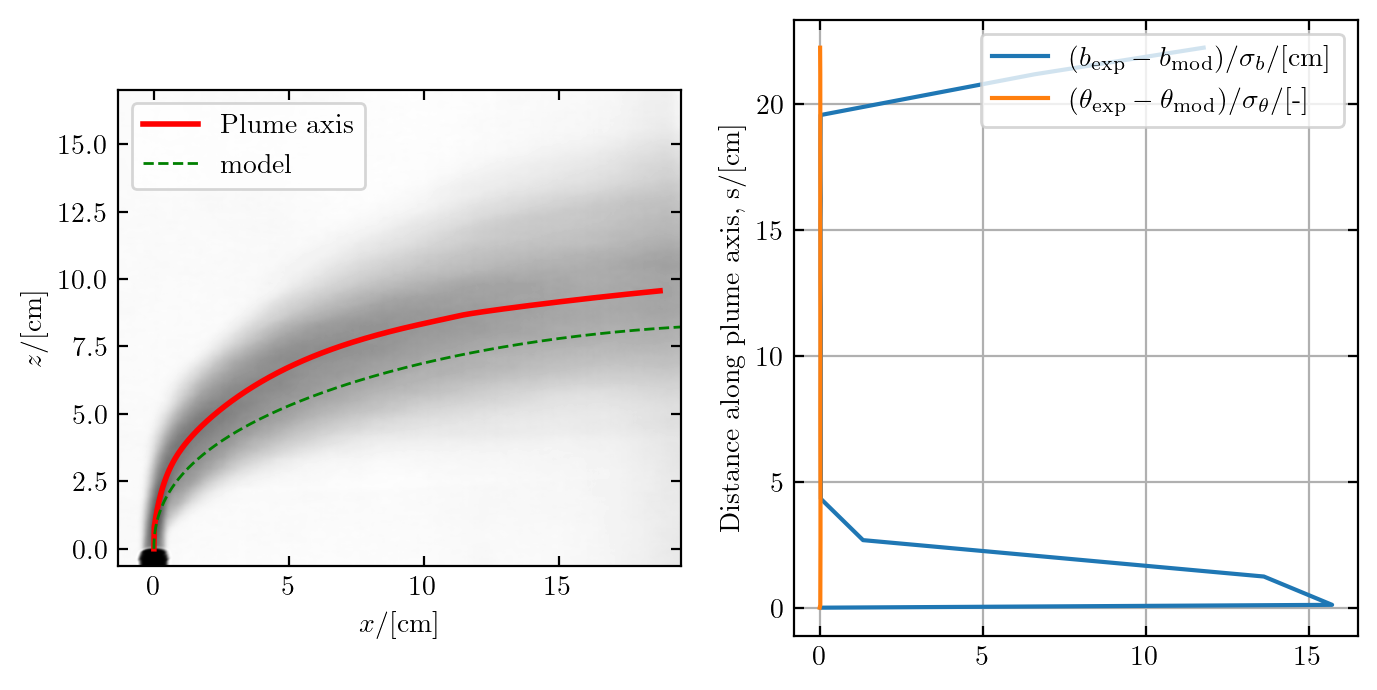

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# On an image of the experimental plume, show the plume trajectories for
# 1) GCTA, 2) our initial guess, 3) the model solution
data, xexp, zexp, extent = load_expt_data(exptNo)
if data.mean() < .5:
    data = 1. - data
ax[0].imshow(data, extent=extent, cmap=plt.cm.gray)
ax[0].invert_yaxis()
ax[0].set_xlabel(r'$x$/[cm]')
ax[0].set_ylabel(r'$z$/[cm]')
# 1) GCTA
ax[0].plot(xexp, zexp, '-r', label='Plume axis', lw=2)
# 2) our initial guess
# ax[0].plot(exptData.axisLocn_x, exptData.axisLocn_y, 'r-', label='Init. guess', lw=2)
# 3) the model solution
ax[0].plot(xmod, zmod, '--g', label='model', lw=1)
ax[0].set_xlim((extent[:2]))
ax[0].legend(loc=2)

ax[1].plot(res[:,0], sexp, '-', label=r'$(b_{\mathrm{exp}} - b_{\mathrm{mod}})/\sigma_b$/[cm]')
ax[1].plot(res[:,1], sexp, '-', label=r'$(\theta_{\mathrm{exp}} - \theta_{\mathrm{mod}})/\sigma_{\theta}$/[-]')
ax[1].legend(loc=1, fancybox=True, framealpha=.8)
ax[1].grid()
ax[1].set_ylabel('Distance along plume axis, s/[cm]')

fig.savefig('plumeAnalyser_solution.png')

# ax[1].set_title('Objective fn: %.3f' % objFn)

(*Left*) Image of experimental plume with calculated and estimated trajectories.  (*Right*) Difference between experimental (guessed) and model solutions as a function of the distance along the plume axis.  

# To do:
- Make a grid of possible initial conditions and run the model for each case.  DONE
- Compare these solutions against the experimental data, computing an objective funtion for each case.  DONE
- Identify which cases produce minima in the objective function.  DONE
- Work in the downhill simplex (or other minimisation routine) to look for minima of the objective function.
- Plot the plume width along with axis track on averaged image.  

In [1]:
# # Uncomment the following line to transform this notebook into a latex file
# !jupyter nbconvert --to latex plumeAnalyser.ipynb

In [11]:
# Now run pdflatex plumeAnalyser from the command line